<a href="https://colab.research.google.com/github/moise97/Extract_-_Structure_Data_from_SDFs_pharmaceutical_documentation/blob/main/Copy_of_Layout_OCR_Pharmaceutical.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Layout-Aware OCR: PaddleOCR & EasyOCR for Pharmaceutical Documents

**Project 4: Advanced OCR Comparison**

In this notebook, you'll explore two powerful layout-aware OCR engines: **PaddleOCR** and **EasyOCR**. Unlike basic Tesseract, these tools understand document structure and can handle complex pharmaceutical certificates with tables, columns, and form-style layouts.

## What You'll Learn
- How to set up and run PaddleOCR on pharmaceutical SDFs
- How to use EasyOCR for quick, reliable text extraction
- How to visualize results with polygon bounding boxes
- How to compare different OCR engines side-by-side

**Sample Document:** [Pharmaceutical SDF - Page 4 (Certificate of Processing)](https://drive.google.com/file/d/1UvYmChia7K90-xjCsHsGqhixmDrPfhHw/view?usp=sharing)

---

## Part 1: PaddleOCR

PaddleOCR is a powerful, layout-aware OCR engine developed by Baidu. It's especially good at:
- Reading text in tables and complex layouts
- Detecting rotated or skewed text
- Providing precise polygon (not just rectangle) bounding boxes

Let's set it up!

In [ ]:
# ============================================
# STEP 1: Install PaddleOCR and All Dependencies
# ============================================
#
# WHAT WE'RE DOING:
# Installing PaddleOCR, PaddlePaddle (its deep learning framework),
# and helper libraries for PDF processing.
#
# WHY THIS MATTERS:
# PaddleOCR needs several tools to work:
# - PaddlePaddle: The engine that powers PaddleOCR (like a car engine)
# - pdf2image + poppler: Convert PDF pages into images
# - langchain: Required by PaddleOCR's internal components
#
# WHAT YOU'LL SEE:
# Lots of installation output - this may take a minute or two.
# You may see some warning messages in red - that's normal!
#
# ⚠️ IMPORTANT: After this cell finishes, go to
#    Runtime → Restart session, then SKIP this cell
#    and continue from the NEXT cell.
# ============================================

# Install PaddleOCR and a compatible version of PaddlePaddle
# We pin specific versions to avoid compatibility issues
!pip install paddleocr==2.9.1 paddlepaddle==2.6.2

# Install PDF conversion tools and langchain (needed by PaddleOCR internals)
!pip install pdf2image langchain langchain-text-splitters

# Install poppler (system tool that helps convert PDFs to images)
!apt-get install poppler-utils -y

print("\n" + "=" * 50)
print("All dependencies installed!")
print("=" * 50)
print("\n⚠️  NOW: Go to Runtime → Restart session")
print("Then SKIP this cell and run the next one.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 2.1 MB/s eta 0:00:00
INFO: pip is looking at multiple versions of opencv-contrib-python to determine which version is compatible with other requirements. This could take a while.
INFO: pip is looking at multiple versions of opencv-python to determine which version is compatible with other requirements. This could take a while.
INFO: pip is looking at multiple versions of opencv-python-headless to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 544.7/544.7 kB 10.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 125.9/125.9 MB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 161.9/161.9 kB 12.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.5/65.5 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  poppler-utils
0 upgraded, 1 newly installed, 0 to remove and 2 not upgraded.
Need to get 186 kB of archives.
After this operation, 697 kB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy-updates/main amd64 poppler-utils amd64 22.02.0-2ubuntu0.12 [186 kB]
Fetched 186 kB in 1s (279 kB/s)
Selecting previously unselected package poppler-utils.
(Reading database ... 117540 files and directories currently installed.)
Preparing to unpack .../poppler-utils_22.02.0-2ubuntu0.12_amd64.deb ...
Unpacking poppler-utils (22.02.0-2ubuntu0.12) ...
Setting up poppler-utils (22.02.0-2ubuntu0.12) ...
Processing triggers for man-db (2.10.2-1) ...

All dependencies installed!

⚠️  NOW: Go to Runtime → Restart session
Then SKIP this cell and run the next one.


In [ ]:
# ============================================
# STEP 1.5: Fix a Known Compatibility Issue
# ============================================
#
# WHAT WE'RE DOING:
# Applying a small fix so PaddleOCR works with the latest
# version of a library called "langchain" that's pre-installed
# in Google Colab.
#
# WHY THIS MATTERS:
# PaddleOCR tries to import from an older version of langchain,
# but Colab has a newer version installed. This fix bridges that gap.
# Without it, you'd get an error when trying to import PaddleOCR.
#
# WHAT YOU'LL SEE:
# A simple confirmation message. No errors = success!
#
# Reference: https://github.com/PaddlePaddle/PaddleOCR/issues/16711
# ============================================

import sys
import types

# Create compatibility bridges for old import paths
# Bridge 1: langchain.docstore.document → langchain_core.documents
m1 = types.ModuleType("langchain.docstore.document")
from langchain_core.documents import Document
m1.Document = Document
sys.modules["langchain.docstore.document"] = m1

# Bridge 2: langchain.text_splitter → langchain_text_splitters
m2 = types.ModuleType("langchain.text_splitter")
from langchain_text_splitters import RecursiveCharacterTextSplitter
m2.RecursiveCharacterTextSplitter = RecursiveCharacterTextSplitter
sys.modules["langchain.text_splitter"] = m2

print("Compatibility fix applied successfully!")

# TIP: This fix is needed as of early 2026. Future versions of
# PaddleOCR may not need it. If you get an error here, make sure
# you ran the install cell first and restarted the runtime.

Compatibility fix applied successfully!


In [ ]:
# ============================================
# STEP 2: Import Libraries
# ============================================
#
# WHAT WE'RE DOING:
# Loading all the tools we need for PaddleOCR.
#
# WHY THIS MATTERS:
# Each library has a specific purpose:
# - PaddleOCR: The main OCR engine
# - pdf2image: Converts PDF pages to images
# - PIL: For displaying and drawing on images
# - matplotlib: For showing results nicely
# - cv2/numpy: For image processing
#
# WHAT YOU'LL SEE:
# A success message if everything loaded correctly.
# ============================================

from paddleocr import PaddleOCR
from pdf2image import convert_from_path
from PIL import Image, ImageDraw
import matplotlib.pyplot as plt
import cv2
import numpy as np
from google.colab import files
import os

print("All libraries imported successfully!")

All libraries imported successfully!


In [ ]:
from google.colab import files
import os
from PIL import Image, ImageDraw
import matplotlib.pyplot as plt
import cv2
import numpy as np

Upload your Pharmaceutical SDF (PDF file):


Saving pharmaceutical-sdf-page4-certificate-processing-1.pdf to pharmaceutical-sdf-page4-certificate-processing-1 (3).pdf

Uploaded: pharmaceutical-sdf-page4-certificate-processing-1 (3).pdf

Converting PDF to image...
Converted 1 page(s)


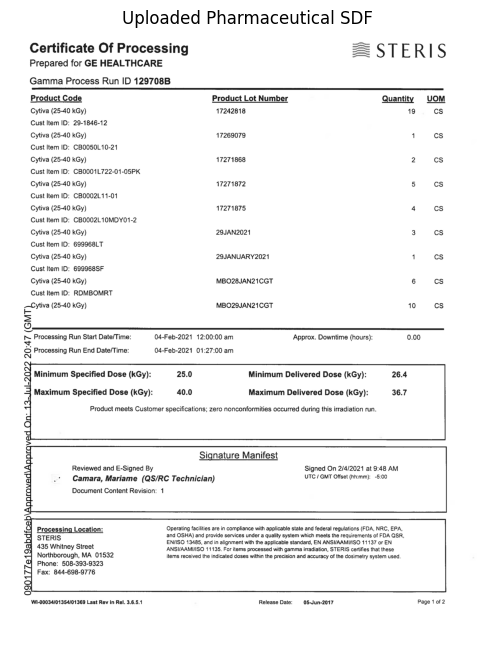

In [ ]:
# ============================================
# STEP 3: Upload Your Pharmaceutical SDF
# ============================================
#
# WHAT WE'RE DOING:
# Uploading and converting the PDF to an image.
#
# WHY THIS MATTERS:
# Like Tesseract, PaddleOCR works on images.
# We'll convert at 300 DPI for high-quality text recognition.
#
# WHAT YOU'LL SEE:
# A preview of your uploaded pharmaceutical document.
# ============================================

print("Upload your Pharmaceutical SDF (PDF file):")
uploaded = files.upload()

# Get the uploaded filename
pdf_filename = list(uploaded.keys())[0]
pdf_path = f"/content/{pdf_filename}"
print(f"\nUploaded: {pdf_filename}")

# Convert PDF to images (high quality)
print("\nConverting PDF to image...")
images = convert_from_path(pdf_path, dpi=300)
print(f"Converted {len(images)} page(s)")

# Save the first page as an image
image = images[0]
image_path = '/content/pharmaceutical_sdf.png'
image.save(image_path, 'PNG')

# Display the image
plt.figure(figsize=(12, 8))
plt.imshow(image)
plt.title('Uploaded Pharmaceutical SDF')
plt.axis('off')
plt.show()

In [ ]:
# ============================================
# STEP 4: Initialize PaddleOCR
# ============================================
#
# WHAT WE'RE DOING:
# Setting up PaddleOCR with English language support.
#
# WHY THIS MATTERS:
# PaddleOCR needs to download model files the first time.
# The 'use_angle_cls=True' option helps detect rotated text.
#
# WHAT YOU'LL SEE:
# Download progress for model files, then a ready message.
# ============================================

print("Initializing PaddleOCR (this may download model files)...")

# Initialize PaddleOCR
ocr = PaddleOCR(
    use_angle_cls=True,  # Enable text angle detection
    lang='en'            # English language
)

print("\nPaddleOCR initialized and ready!")

# TIP: If you see warnings about GPU, that's okay - it will use CPU instead.

Initializing PaddleOCR (this may download model files)...
download https://paddleocr.bj.bcebos.com/PP-OCRv3/english/en_PP-OCRv3_det_infer.tar to /root/.paddleocr/whl/det/en/en_PP-OCRv3_det_infer/en_PP-OCRv3_det_infer.tar


100%|██████████| 3910/3910 [00:18<00:00, 217.08it/s] 


download https://paddleocr.bj.bcebos.com/PP-OCRv4/english/en_PP-OCRv4_rec_infer.tar to /root/.paddleocr/whl/rec/en/en_PP-OCRv4_rec_infer/en_PP-OCRv4_rec_infer.tar


100%|██████████| 10000/10000 [00:20<00:00, 483.55it/s]


download https://paddleocr.bj.bcebos.com/dygraph_v2.0/ch/ch_ppocr_mobile_v2.0_cls_infer.tar to /root/.paddleocr/whl/cls/ch_ppocr_mobile_v2.0_cls_infer/ch_ppocr_mobile_v2.0_cls_infer.tar


100%|██████████| 2138/2138 [00:01<00:00, 1289.47it/s]

[2026/02/03 22:06:55] ppocr DEBUG: Namespace(help='==SUPPRESS==', use_gpu=False, use_xpu=False, use_npu=False, use_mlu=False, ir_optim=True, use_tensorrt=False, min_subgraph_size=15, precision='fp32', gpu_mem=500, gpu_id=0, image_dir=None, page_num=0, det_algorithm='DB', det_model_dir='/root/.paddleocr/whl/det/en/en_PP-OCRv3_det_infer', det_limit_side_len=960, det_limit_type='max', det_box_type='quad', det_db_thresh=0.3, det_db_box_thresh=0.6, det_db_unclip_ratio=1.5, max_batch_size=10, use_dilation=False, det_db_score_mode='fast', det_east_score_thresh=0.8, det_east_cover_thresh=0.1, det_east_nms_thresh=0.2, det_sast_score_thresh=0.5, det_sast_nms_thresh=0.2, det_pse_thresh=0, det_pse_box_thresh=0.85, det_pse_min_area=16, det_pse_scale=1, scales=[8, 16, 32], alpha=1.0, beta=1.0, fourier_degree=5, rec_algorithm='SVTR_LCNet', rec_model_dir='/root/.paddleocr/whl/rec/en/en_PP-OCRv4_rec_infer', rec_image_inverse=True, rec_image_shape='3, 48, 320', rec_batch_num=6, max_text_length=25, rec_c


PaddleOCR initialized and ready!


In [ ]:
# ============================================
# STEP 5: Run PaddleOCR on the Pharmaceutical SDF
# ============================================
#
# WHAT WE'RE DOING:
# Running OCR to extract text and bounding boxes.
#
# WHY THIS MATTERS:
# PaddleOCR returns detailed results:
# - The actual text detected
# - Confidence scores (how sure it is)
# - Polygon coordinates (4 corners of the text box)
#
# WHAT YOU'LL SEE:
# Progress messages as it processes the document.
# ============================================

print("Running PaddleOCR on your pharmaceutical document...")
print("(This may take a moment)")

# Run OCR
result = ocr.ocr(image_path)

print("\nOCR complete!")
print(f"Detected {len(result[0]) if result[0] else 0} text regions")

# TIP: result[0] contains all detected text regions from page 1

Running PaddleOCR on your pharmaceutical document...
(This may take a moment)
[2026/02/03 22:06:57] ppocr DEBUG: dt_boxes num : 100, elapsed : 0.4838857650756836
[2026/02/03 22:06:58] ppocr DEBUG: cls num  : 100, elapsed : 0.2850348949432373
[2026/02/03 22:07:12] ppocr DEBUG: rec_res num  : 100, elapsed : 14.074315786361694

OCR complete!
Detected 97 text regions


In [ ]:
# ============================================
# STEP 6: Display Sample Results
# ============================================
#
# WHAT WE'RE DOING:
# Showing you what PaddleOCR found in a readable format.
#
# WHY THIS MATTERS:
# Before drawing boxes, let's see the raw output.
# Each result has: [polygon_box, (text, confidence)]
#
# WHAT YOU'LL SEE:
# A list of detected text with confidence scores.
# ============================================

print("Sample of PaddleOCR Results:")
print("=" * 60)

# Show first 15 results
for i, line in enumerate(result[0][:15]):
    box = line[0]  # Polygon coordinates
    text = line[1][0]  # Detected text
    confidence = line[1][1]  # Confidence score

    print(f"{i+1:2d}. [{confidence:.2%}] {text}")

if len(result[0]) > 15:
    print(f"\n... and {len(result[0]) - 15} more text regions!")

# TIP: Confidence scores above 90% are usually very reliable.

Sample of PaddleOCR Results:
 1. [97.84%] Certificate Of Processing
 2. [90.92%] STERIS
 3. [99.92%] Prepared for GE HEALTHCARE
 4. [99.10%] Gamma Process Run ID 129708B
 5. [99.99%] Product Code
 6. [99.11%] Product Lot Number
 7. [99.40%] Quantity
 8. [99.53%] UOM
 9. [99.99%] Cytiva (25-40 kGy)
10. [98.58%] 17242818
11. [99.97%] 19
12. [65.16%] cs
13. [99.56%] Cust Item ID: 29-1846-12
14. [98.03%] Cytiva (25-40 kGy)
15. [99.99%] 17269079

... and 82 more text regions!


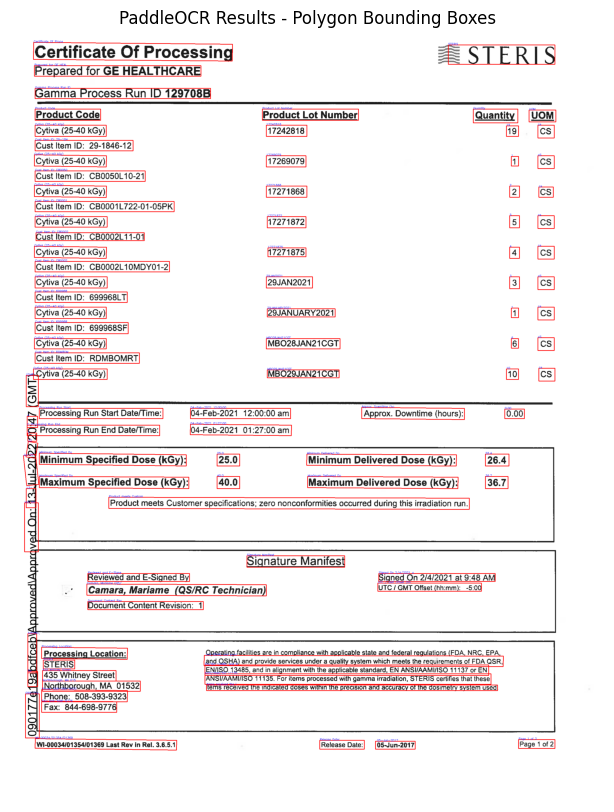

In [ ]:
# ============================================
# STEP 7: Draw Polygon Bounding Boxes
# ============================================
#
# WHAT WE'RE DOING:
# Drawing boxes around every text region PaddleOCR found.
#
# WHY THIS MATTERS:
# Unlike Tesseract's rectangles, PaddleOCR gives us polygons!
# Polygons can follow tilted or skewed text more precisely.
#
# WHAT YOU'LL SEE:
# Your document with red polygon boxes around all detected text.
# ============================================

# Load the original image with OpenCV
img = cv2.imread(image_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # Convert to RGB for display

# Draw polygons for each detected text region
for line in result[0]:
    box = line[0]  # Get the polygon coordinates
    text = line[1][0]  # Get the text
    score = line[1][1]  # Get confidence

    # Only draw for high-confidence detections
    if score > 0.5:
        # Convert box coordinates to integers
        box = [(int(x), int(y)) for x, y in box]

        # Draw the polygon (4-sided shape) in red
        cv2.polylines(img, [np.array(box)], isClosed=True,
                      color=(255, 0, 0), thickness=2)

        # Add the text label near the first corner in blue
        cv2.putText(img, text[:20], box[0],
                    cv2.FONT_HERSHEY_SIMPLEX, 0.4, (0, 0, 255), 1)

# Display the result
plt.figure(figsize=(15, 10))
plt.imshow(img)
plt.title('PaddleOCR Results - Polygon Bounding Boxes')
plt.axis('off')
plt.show()

# TIP: Notice how polygons can capture tilted text better than rectangles!

---

## Part 2: EasyOCR

EasyOCR is a simpler, faster alternative to PaddleOCR. It's:
- Very easy to install and use
- Good for scanned forms and simple layouts
- Faster to set up than PaddleOCR

Let's try it on the same document!

In [ ]:

# ============================================
# STEP 8: Install and Import EasyOCR
# ============================================
#
# WHAT WE'RE DOING:
# Setting up EasyOCR - it's much simpler than PaddleOCR!
#
# WHY THIS MATTERS:
# Sometimes simpler is better. EasyOCR is:
# - Faster to install
# - Easier to use
# - Still quite accurate
#
# WHAT YOU'LL SEE:
# Installation progress, then a ready message.
# ============================================

!pip install easyocr

import easyocr

print("\nEasyOCR installed and imported!")


EasyOCR installed and imported!


In [ ]:
# ============================================
# STEP 9: Initialize EasyOCR Reader
# ============================================
#
# WHAT WE'RE DOING:
# Creating an EasyOCR reader for English text.
#
# WHY THIS MATTERS:
# EasyOCR downloads model files on first use.
# After that, initialization is very fast.
#
# WHAT YOU'LL SEE:
# Model download progress (first time only).
# ============================================

print("Initializing EasyOCR reader...")

# Create a reader for English
reader = easyocr.Reader(['en'])

print("EasyOCR reader ready!")

# TIP: You can add more languages like ['en', 'fr'] for multilingual documents.

Initializing EasyOCR reader...
EasyOCR reader ready!


In [ ]:
# ============================================
# STEP 10: Run EasyOCR on the Pharmaceutical SDF
# ============================================
#
# WHAT WE'RE DOING:
# Processing the same document with EasyOCR.
#
# WHY THIS MATTERS:
# This lets us compare EasyOCR results with PaddleOCR!
# Each engine may find different things.
#
# WHAT YOU'LL SEE:
# Processing time and number of text regions found.
# ============================================

print("Running EasyOCR on your pharmaceutical document...")

# Run OCR
easy_result = reader.readtext(image_path)

print(f"\nEasyOCR found {len(easy_result)} text regions!")

# TIP: EasyOCR typically runs faster than PaddleOCR.

Running EasyOCR on your pharmaceutical document...


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)



EasyOCR found 92 text regions!


In [ ]:
# ============================================
# STEP 11: Display EasyOCR Results
# ============================================
#
# WHAT WE'RE DOING:
# Showing what EasyOCR found.
#
# WHY THIS MATTERS:
# EasyOCR returns: (bounding_box, text, confidence)
# The bounding box is 4 corner points.
#
# WHAT YOU'LL SEE:
# A list of detected text with confidence scores.
# ============================================

print("Sample of EasyOCR Results:")
print("=" * 60)

# Show first 15 results
for i, (bbox, text, confidence) in enumerate(easy_result[:15]):
    print(f"{i+1:2d}. [{confidence:.2%}] {text}")

if len(easy_result) > 15:
    print(f"\n... and {len(easy_result) - 15} more text regions!")

Sample of EasyOCR Results:
 1. [96.23%] Certificate Of Processing
 2. [83.11%] STERIS
 3. [86.72%] Prepared for GE HEALTHCARE
 4. [99.64%] Gamma Process Run ID 129708B
 5. [95.65%] Product Code
 6. [65.81%] Product_Lot Number
 7. [96.65%] Quantity
 8. [72.04%] UQM
 9. [77.64%] Cytiva (25-40 kGy)
10. [99.95%] 17242818
11. [100.00%] 19
12. [98.96%] CS
13. [75.63%] Cust Item ID: 29-1846-12
14. [87.99%] Cytiva (25-40 kGy)
15. [83.57%] 17269079

... and 77 more text regions!


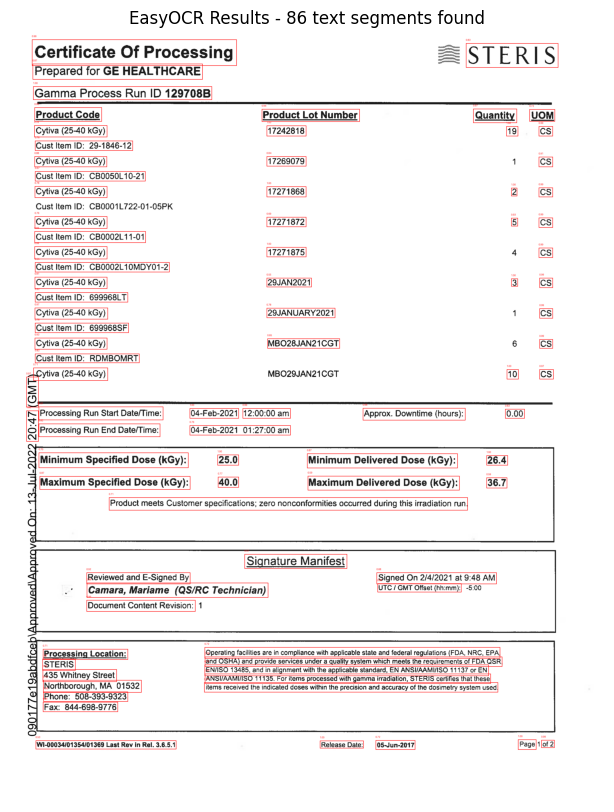

In [ ]:
# ============================================
# STEP 12: Visualize EasyOCR Results
# ============================================
#
# WHAT WE'RE DOING:
# Drawing boxes around EasyOCR detections.
#
# WHY THIS MATTERS:
# Visual comparison helps us see differences between engines.
#
# WHAT YOU'LL SEE:
# Your document with red boxes around EasyOCR detections.
# ============================================

# Load a fresh copy of the image
img_easy = image.copy()
draw = ImageDraw.Draw(img_easy)

# Collect high-confidence text
extracted_text = []

for (bbox, text, confidence) in easy_result:
    if confidence > 0.5:  # Only show high-confidence results
        # Get bounding box corners
        top_left = tuple(map(int, bbox[0]))
        bottom_right = tuple(map(int, bbox[2]))

        # Draw rectangle
        draw.rectangle([top_left, bottom_right], outline='red', width=2)

        # Add confidence score
        draw.text((top_left[0], top_left[1] - 20), f"{confidence:.2f}", fill='red')

        extracted_text.append(text)

# Display
plt.figure(figsize=(15, 10))
plt.imshow(img_easy)
plt.title(f'EasyOCR Results - {len(extracted_text)} text segments found')
plt.axis('off')
plt.show()

# TIP: Compare this with the PaddleOCR visualization above!

---

## Part 3: Side-by-Side Comparison

Now let's compare PaddleOCR and EasyOCR results to see which works better for pharmaceutical documents!

In [ ]:
# ============================================
# STEP 13: Compare OCR Engine Statistics
# ============================================
#
# WHAT WE'RE DOING:
# Comparing basic statistics from both OCR engines.
#
# WHY THIS MATTERS:
# Numbers help us objectively compare performance.
#
# WHAT YOU'LL SEE:
# A comparison table of key metrics.
# ============================================

# Calculate statistics for PaddleOCR
paddle_count = len(result[0]) if result[0] else 0
paddle_confidences = [line[1][1] for line in result[0]] if result[0] else []
paddle_avg_conf = sum(paddle_confidences) / len(paddle_confidences) if paddle_confidences else 0

# Calculate statistics for EasyOCR
easy_count = len(easy_result)
easy_confidences = [conf for (_, _, conf) in easy_result]
easy_avg_conf = sum(easy_confidences) / len(easy_confidences) if easy_confidences else 0

# Print comparison
print("OCR Engine Comparison")
print("=" * 55)
print(f"{'Metric':<25} {'PaddleOCR':<15} {'EasyOCR':<15}")
print("-" * 55)
print(f"{'Text regions detected:':<25} {paddle_count:<15} {easy_count:<15}")
print(f"{'Average confidence:':<25} {f'{paddle_avg_conf:.2%}':<15} {f'{easy_avg_conf:.2%}':<15}")
print(f"{'High conf (>90%):':<25} {sum(1 for c in paddle_confidences if c > 0.9):<15} {sum(1 for c in easy_confidences if c > 0.9):<15}")
print(f"{'Low conf (<50%):':<25} {sum(1 for c in paddle_confidences if c < 0.5):<15} {sum(1 for c in easy_confidences if c < 0.5):<15}")

# TIP: More detections isn't always better - accuracy matters too!

NameError: name 'result' is not defined

In [ ]:
# ============================================
# STEP 14: Check for Key Pharmaceutical Terms
# ============================================
#
# WHAT WE'RE DOING:
# Checking if each engine found important pharmaceutical terms.
#
# WHY THIS MATTERS:
# For pharmaceutical compliance, we need to extract specific fields.
# The "best" OCR is the one that finds what we need!
#
# WHAT YOU'LL SEE:
# Which engine found which key terms.
# ============================================

# Define key pharmaceutical terms
key_terms = ["CERTIFICATE", "LOT", "BATCH", "VENDOR", "EXPIRATION",
             "DATE", "COA", "MANUFACTURER", "STERIS", "PROCESSING", "QUALITY"]

# Get all text from each engine (uppercase for matching)
paddle_texts = [line[1][0].upper() for line in result[0]] if result[0] else []
easy_texts = [text.upper() for (_, text, _) in easy_result]

# Check which terms were found
print("Key Pharmaceutical Terms Found:")
print("=" * 50)
print(f"{'Term':<15} {'PaddleOCR':<12} {'EasyOCR':<12}")
print("-" * 50)

for term in key_terms:
    paddle_found = any(term in text for text in paddle_texts)
    easy_found = any(term in text for text in easy_texts)

    paddle_mark = "Found" if paddle_found else "--"
    easy_mark = "Found" if easy_found else "--"

    print(f"{term:<15} {paddle_mark:<12} {easy_mark:<12}")

# TIP: Try running this on different pages to see consistency!

---

## Congratulations!

You've now explored two powerful layout-aware OCR engines:

1. **PaddleOCR** - More powerful, better at complex layouts
2. **EasyOCR** - Simpler, faster, good for straightforward documents

### Key Takeaways

| Feature | PaddleOCR | EasyOCR |
|---------|-----------|----------|
| Setup complexity | Moderate | Easy |
| Layout awareness | Excellent | Good |
| Speed | Moderate | Fast |
| Polygon boxes | Yes | Yes |
| Best for | Complex layouts, tables | Simple forms, quick results |

In the next module, you'll run a formal comparison task using all three engines (Tesseract, PaddleOCR, EasyOCR) on the same pharmaceutical documents!